# 📈 04 - Évaluation Finale des Modèles

**Objectif:** Évaluer le modèle final retenu sur le jeu de test totalement intact, après sélection et réglage du seuil sur la validation.

In [8]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from src.evaluate import evaluate_model
from config.settings import DATA_PROCESSED, MODELS_DIR, MODEL_FILENAME

# Chargement des données de validation et de test
val_df = pd.read_csv(DATA_PROCESSED / 'val.csv')
test_df = pd.read_csv(DATA_PROCESSED / 'test.csv')

X_val = val_df.drop(columns=['Class'])
y_val = val_df['Class']
X_test = test_df.drop(columns=['Class'])
y_test = test_df['Class']

print(f"X_val: {X_val.shape}")
print(f"Distribution val: {y_val.value_counts().to_dict()}")
print(f"X_test: {X_test.shape}")
print(f"Distribution test: {y_test.value_counts().to_dict()}")

X_val: (42559, 39)
Distribution val: {0: 42488, 1: 71}
X_test: (42559, 39)
Distribution test: {0: 42488, 1: 71}


## 1. Chargement des modèles

In [9]:
# Chargement du modèle final retenu par la validation
best_model = joblib.load(MODELS_DIR / MODEL_FILENAME)
print(f"✅ Modèle final chargé depuis {MODEL_FILENAME}")

✅ Modèle final chargé depuis best_model.joblib


## 2. Évaluation finale

In [10]:
# Évaluation finale sur le test totalement intact
test_metrics = evaluate_model(best_model, X_test, y_test)

print("\n" + "="*70)
print("EVALUATION FINALE SUR TEST")
print("="*70)
print(pd.Series({k: v for k, v in test_metrics.items() if k != 'confusion_matrix'}).to_string(float_format='{:.4f}'.format))

2026-05-25 13:19:43.813 | INFO     | src.evaluate:evaluate_model:40 - === EVALUATION (test set) ===
2026-05-25 13:19:43.814 | INFO     | src.evaluate:evaluate_model:43 -   accuracy: 0.9994
2026-05-25 13:19:43.814 | INFO     | src.evaluate:evaluate_model:43 -   precision: 0.9412
2026-05-25 13:19:43.815 | INFO     | src.evaluate:evaluate_model:43 -   recall: 0.6761
2026-05-25 13:19:43.815 | INFO     | src.evaluate:evaluate_model:43 -   f1_score: 0.7869
2026-05-25 13:19:43.815 | INFO     | src.evaluate:evaluate_model:43 -   roc_auc: 0.9505
2026-05-25 13:19:43.815 | INFO     | src.evaluate:evaluate_model:43 -   pr_auc: 0.8137
2026-05-25 13:19:43.816 | INFO     | src.evaluate:evaluate_model:44 -   TN=42485 FP=3 FN=23 TP=48



EVALUATION FINALE SUR TEST
accuracy    0.9994
precision   0.9412
recall      0.6761
f1_score    0.7869
roc_auc     0.9505
pr_auc      0.8137


## 3. Analyse détaillée du modèle final

In [11]:
from sklearn.metrics import classification_report

print("Rapport de classification sur le test final:")
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Légitime', 'Fraude']))

Rapport de classification sur le test final:
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     42488
      Fraude       0.94      0.68      0.79        71

    accuracy                           1.00     42559
   macro avg       0.97      0.84      0.89     42559
weighted avg       1.00      1.00      1.00     42559



## 4. Analyse des erreurs

Seuil retenu sur validation: 0.45
Faux Positifs (légitime classé fraude): 3
Faux Négatifs (fraude non détectée): 20

Taux de détection des fraudes (Recall): 71.83%


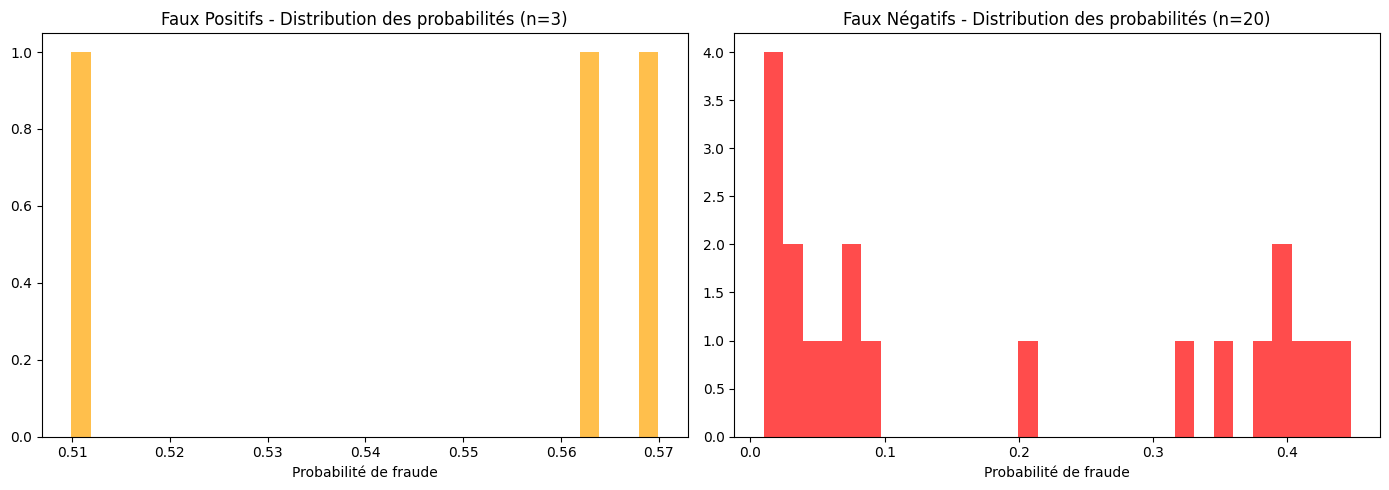

In [14]:
y_proba = best_model.predict_proba(X_test)[:, 1]
val_proba = best_model.predict_proba(X_val)[:, 1]

# Seuil choisi sur validation uniquement
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score

thresholds = np.arange(0.1, 0.9, 0.05)
metrics_by_threshold = []
for t in thresholds:
    y_pred_t = (val_proba >= t).astype(int)
    metrics_by_threshold.append({
        'threshold': t,
        'precision': precision_score(y_val, y_pred_t, zero_division=0),
        'recall': recall_score(y_val, y_pred_t, zero_division=0),
        'f1': f1_score(y_val, y_pred_t, zero_division=0),
    })

thresh_df = pd.DataFrame(metrics_by_threshold)
best_threshold = thresh_df.loc[thresh_df['f1'].idxmax(), 'threshold']

# Application du seuil choisi au test, sans le tuner sur le test
y_pred_threshold = (y_proba >= best_threshold).astype(int)
fp_mask = (y_pred_threshold == 1) & (y_test == 0)
fn_mask = (y_pred_threshold == 0) & (y_test == 1)

print(f"Seuil retenu sur validation: {best_threshold:.2f}")
print(f"Faux Positifs (légitime classé fraude): {fp_mask.sum()}")
print(f"Faux Négatifs (fraude non détectée): {fn_mask.sum()}")
print(f"\nTaux de détection des fraudes (Recall): {1 - fn_mask.sum()/y_test.sum():.2%}")

# Distribution des probabilités pour les erreurs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_proba[fp_mask], bins=30, color='orange', alpha=0.7)
axes[0].set_title(f'Faux Positifs - Distribution des probabilités (n={fp_mask.sum()})')
axes[0].set_xlabel('Probabilité de fraude')

axes[1].hist(y_proba[fn_mask], bins=30, color='red', alpha=0.7)
axes[1].set_title(f'Faux Négatifs - Distribution des probabilités (n={fn_mask.sum()})')
axes[1].set_xlabel('Probabilité de fraude')

plt.tight_layout()
plt.savefig('../figures/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Optimisation du seuil sur validation

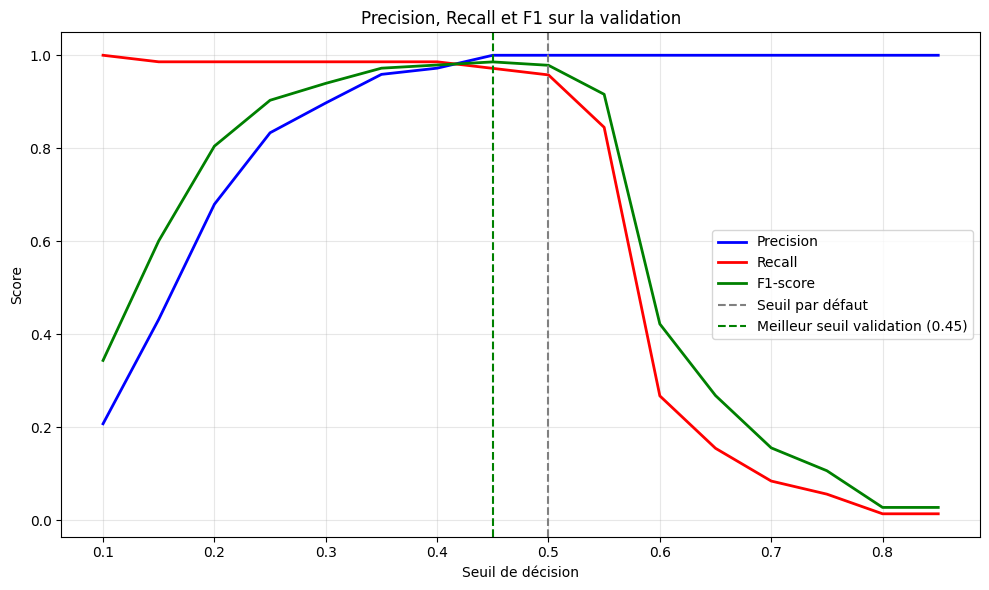


Seuil optimal (validation F1): 0.45
F1 validation au seuil optimal: 0.9857
F1 test au seuil retenu: 0.8160
PR-AUC test inchangé: 0.8137


In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresh_df['threshold'], thresh_df['precision'], 'b-', label='Precision', linewidth=2)
ax.plot(thresh_df['threshold'], thresh_df['recall'], 'r-', label='Recall', linewidth=2)
ax.plot(thresh_df['threshold'], thresh_df['f1'], 'g-', label='F1-score', linewidth=2)
ax.axvline(x=0.5, color='gray', linestyle='--', label='Seuil par défaut')
ax.axvline(x=best_threshold, color='green', linestyle='--', label=f'Meilleur seuil validation ({best_threshold:.2f})')

ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall et F1 sur la validation')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSeuil optimal (validation F1): {best_threshold:.2f}")
print(f"F1 validation au seuil optimal: {thresh_df['f1'].max():.4f}")

# Application du seuil optimal sur test
print(f"F1 test au seuil retenu: {f1_score(y_test, y_pred_threshold):.4f}")
print(f"PR-AUC test inchangé: {average_precision_score(y_test, y_proba):.4f}")

## 6. Conclusions

- Les métriques principales à retenir sont **PR-AUC**, **F1-score**, **precision** et **recall**.
- Le seuil de décision est choisi sur la validation, puis appliqué une seule fois au test.
- L'accuracy reste informative mais n'est pas la métrique de pilotage sur ce dataset très déséquilibré.

Le modèle final est prêt pour le déploiement via l'API FastAPI.